# Lab 3: Stochastic Gradient Descent

Welcome to the advanced Machine Learning Course.

The objective of this lab session is to code a few regression algorithms and to apply them to synthetic and real datasets.

Please put **"ML - MDS - TD3"** in the mail subject or I might lose your work (which means 0) and send it to pierre.houdouin@centralesupelec.fr

Please label your notebook **"L3_familyname1_familyname2.ipynb"** or I might lose your work (which means 0).

We begin with the standard imports:

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import f1_score
from sklearn import model_selection, linear_model, metrics

import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

We import the dataset that we are going to use, an indian dataset including in the last column information about the diabetes status of patients:

In [2]:
data = pd.read_csv("w8a.csv", sep=";", header=None)

X = data.iloc[:, :-1].to_numpy()
y = data.iloc[:, -1].to_numpy()
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.33, random_state=32
)

## Logistic Regression



Today we'll be moving from linear regression to logistic regression, one of the simplest ways to deal with a classification problem. Instead of fitting a line, logistic regression models the probability that the outcome is 1 given the value of the predictor. In order to do this we need a function that transforms our predictor variable to a value between 0 and 1. Lots of functions can do that, but the logistic function is the most common choice:

$$f(z) = \frac{1}{1+\exp{-z}}.$$

To predict the class of our observations we'll have to minimize the corresponding loss function and as we are in a high-dimensional context we'll add an $l_2$ regularization to the model:

$$L(\textbf{w}) = \sum_{i=1}^n log(1+\exp(-y_i\textbf{w}^Tx_i))+\frac{\lambda}{2} \| \textbf{w} \|^2,$$

where $x_i$ is the vector of features for the observation $i$ and $y_i \in \{-1, 1\}$ is the class label.  


We first use the `sklearn` implementation:

In [3]:
logistic_regression = linear_model.LogisticRegression(
    penalty="l2", C=1.0, max_iter=1000
)

logistic_regression.fit(X_train, y_train)
y_pred = logistic_regression.predict(X_test)

and we compute the accuracy score to evaluate the model performance:

Accuracy: 0.9837
              precision    recall  f1-score   support

          -1       0.99      1.00      0.99     15884
           1       0.89      0.57      0.69       534

    accuracy                           0.98     16418
   macro avg       0.94      0.78      0.84     16418
weighted avg       0.98      0.98      0.98     16418



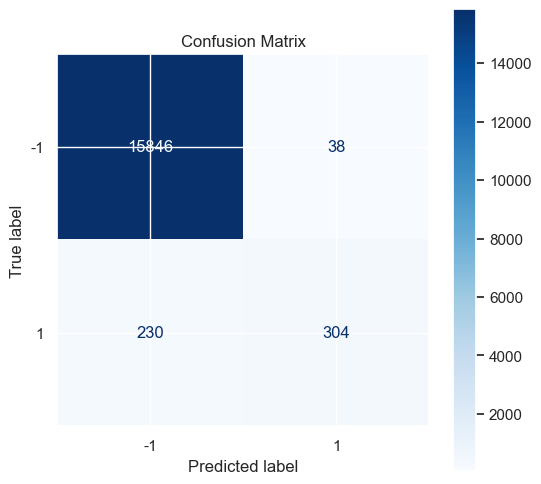

In [4]:
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(metrics.classification_report(y_test, y_pred))

cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=logistic_regression.classes_
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=True)
plt.title("Confusion Matrix")
plt.show()

### Assignment

Implement from scratch your own logistic regression model with stochastic gradient descent optimization. 

- Fill in the class

- Display the evolution of the cost function along iterations. Do this for several strategies for the setting of the learning rate

- Try the different acceleration strategies

- Train the model with the training set and evaluate its performance in the test set

In [5]:
class StochasticLogisticRegression:
    """Class for logistic regression:

    Attributes:
    -----------                                                                              Default value
    coef_         : 1-dimensional np.array, coefficients / weights                         | None
    lambd_        : float,                  regularization parameter                       | 0.1
    lr_           : float,                  the learning rate                              | 0.01
    bsize         : integer,                the size of the mini-batch >=1                 | 64
    gamma         : float,                  gamma coefficient                              | 0.999
    beta          : float,                  beta coefficient                               | 0.9
    eps           : float,                  epsilon coefficient                            | 10-8
    debias        : boolean,                indicates if we use the debiais correction     | False
    coef_history_ : list,                   the list of all visited betas/ weights         | []
    f_history_    : list ,                  the list of all evaluations in visited betas   | []
    acc_history_  : list ,                  the list of all accuracies in visited betas    | []
    thresh        : float,                  decision threshold for classification          | 0.5
    """

    def __init__(
        self,
        lambd=0.1,
        lr=1e-2,
        batchsize=64,
        gamma=0.999,
        beta=0.9,
        eps=1e-8,
        debias=False,
        thresh=0.5,
    ):
        self.coef_ = None  # weights
        self.lambd_ = lambd
        self.lr_ = lr
        self.bsize_ = batchsize
        self.gamma_ = gamma
        self.beta_ = beta
        self.eps_ = eps
        self.debias_ = debias
        self.coef_history_ = []
        self.f_history_ = []
        self.acc_history_ = []
        self.thresh_ = thresh

    def logistic(self, z):
        return 1.0 / (1.0 + np.exp(-z))

    def fit(self, X, y, lr=1e-2, bsize=64, max_iter=100, minibatch=False):
        """Fit the data (X, y).

        Parameters:
        -----------                                                                         Default value
        X          : (num_samples, num_features) np.array, Design matrix                  |
        y          : (num_sampes, ) np.array,              Output vector                  |
        lr         : float,                                the learning rate              | 0.001
        bsize      : integer,                              the size of the mini-batch >=1 | 64
        max_iter   : integer,                              the number of epochs           | 100
        mini_batch : bool,                                 method used                    | False
        """
        n, d = X.shape
        self.coef_ = np.zeros(d)

        moment = np.zeros_like(self.coef_)
        velocity = np.zeros_like(self.coef_)
        t = 0

        # bsize can be set in model and in fit function
        batch_size = bsize if minibatch else n

        for epoch in tqdm(range(max_iter)):
            idx = np.random.permutation(n)
            X_, y_ = X[idx], y[idx]

            for start in range(0, n, batch_size):
                t += 1
                end = start + batch_size
                X_batch, y_batch = X_[start:end], y_[start:end]

                # ADAM
                z = X_batch @ self.coef_
                probability = self.logistic(y_batch * z)

                gradient = (
                    -X_batch.T @ (y_batch * (1 - probability)) / X_batch.shape[0]
                    + self.lambd_ * self.coef_
                )

                moment = self.beta_ * moment + (1 - self.beta_) * gradient
                velocity = self.gamma_ * velocity + (1 - self.gamma_) * gradient**2

                if self.debias_:
                    moment_corrected = moment / (1 - self.beta_**t)
                    velocity_corrected = velocity / (1 - self.gamma_**t)
                else:
                    moment_corrected = moment
                    velocity_corrected = velocity

                self.coef_ -= (
                    self.lr_
                    * moment_corrected
                    / (np.sqrt(velocity_corrected) + self.eps_)
                )

            z_ = X @ self.coef_
            probability = self.logistic(z_)

            # Compute loss
            loss = np.mean(np.log(1 + np.exp(-y * z_)))
            reg = (self.lambd_ / 2) * np.sum(self.coef_**2)
            self.f_history_.append(loss + reg)
            self.coef_history_.append(self.coef_.copy())

            # Compute accuracy over epochs
            y_pred = np.where(probability >= self.thresh_, 1, -1)

            acc = np.mean(y_pred == y)
            self.acc_history_.append(acc)

    def predict(self, X):
        """Make binary predictions for data X.

        Parameters:
        -----------
        X: (num_samples, num_features) np.array, Design matrix

        Returns:
        -----
        y_pred: (num_samples, ) np.array, Predictions (0 or 1)
        """
        probability = self.logistic(X @ self.coef_)
        return np.where(probability >= self.thresh_, 1, -1)

    def accuracy_evaluation(self, X, y, thresh=None, margin=0, vizualisation=True):
        """Compute detailed accuracy rates.

        Parameters:
        -----------                                                              Default value
        X                : (num_samples, num_features) np.array, Input data    |
        y                : (num_samples, ) np.array, Labels of the input data  |
        thresh           : Decision threshold                                  | 0.5
        margin           : If the prediction is at a distance less than margin | 0
                           to the treshold, returns undetermined label.        |
        vizualisation    : Allow the user to vizualize in a board the results  | True

        Returns:
        -----
        good_prediction  : % of correct classifications
        undetermined     : % of indetermined labels
        wrong_prediction : % of wrong classifications
        TP               : % of 1 labelled 1
        UP               : % of 1 labelled undetermined
        FN               : % of 1 labelled -1
        TN               : % of -1 labelled -1
        UN               : % of -1 labelled undetermined
        FP               : % of -1 labelled 1
        F1_score         : F1-score
        """
        probability = self.logistic(X @ self.coef_)

        thresh = self.thresh_ if thresh is None else thresh
        pred = np.full_like(y, 0, dtype=int)
        pred[probability >= thresh + margin] = 1
        pred[probability <= thresh - margin] = -1

        TP = np.sum((y == 1) & (pred == 1))
        TN = np.sum((y == -1) & (pred == -1))
        FP = np.sum((y == -1) & (pred == 1))
        FN = np.sum((y == 1) & (pred == -1))
        UP = np.sum((y == 1) & (pred == 0))
        UN = np.sum((y == -1) & (pred == 0))
        total = len(y)

        good = (TP + TN) / total
        undetermined = (UP + UN) / total
        wrong = (FP + FN) / total

        precision = TP / (TP + FP + 1e-10)
        recall = TP / (TP + FN + 1e-10)
        F1 = 2 * (precision * recall) / (precision + recall + 1e-10)

        if vizualisation:
            print(f"Good predictions: {good * 100:.2f}%")
            print(f"Undetermined: {undetermined * 100:.2f}%")
            print(f"Wrong predictions: {wrong * 100:.2f}%")
            print(f"TP: {TP} | UP: {UP} | FN: {FN}")
            print(f"TN: {TN} | UN: {UN} | FP: {FP}")
            print(f"F1-score: {F1:.4f}")

        return good, undetermined, wrong, TP, UP, FN, TN, UN, FP, F1

    def find_thresh(self, X, y, step=0.01, margin=0):
        """Find the decision threshsold that maximize the f1_score

        Parameters:
        -----------                                                    Default value
        X      : (num_samples, num_features) np.array, Input data    |
        y      : (num_samples, ) np.array, Labels of the input data  |
        step   : Decision threshold                                  | 0.5
        margin : If the prediction is at a distance less than margin | 0
                 to the treshold, returns undetermined label.        |
        """
        best_thresh = self.thresh_
        best_f1 = 0
        hist = []
        for t in np.arange(0, 1, step):
            _, _, _, _, _, _, _, _, _, F1 = self.accuracy_evaluation(
                X, y, thresh=t, margin=margin, vizualisation=False
            )
            hist.append((t, F1))
            if F1 > best_f1:
                best_f1 = F1
                best_thresh = t
        self.thresh_ = best_thresh
        return best_thresh, best_f1, hist

Apply to the data

On essaie plusieurs entraînements avec différents coefficients de régularisation, on choisit celui qui minimise
l'erreur sur le test set. On entraine sur 1000 itérations en batch gradient descent. On garde **lambda = 2**.
On essaie ensuite plusieurs learning rates, on choisit le plus grand qui permet d'obtenir un gradient qui converge. On garde **lr = 0.01**.

In [6]:
# Parameters
lambda_ = 2
lr = 0.01
max_iter = 1000

## Optimal threshold

100%|██████████| 1000/1000 [00:14<00:00, 67.98it/s]


Best threshold: 0.48 with F1-score: 0.0972


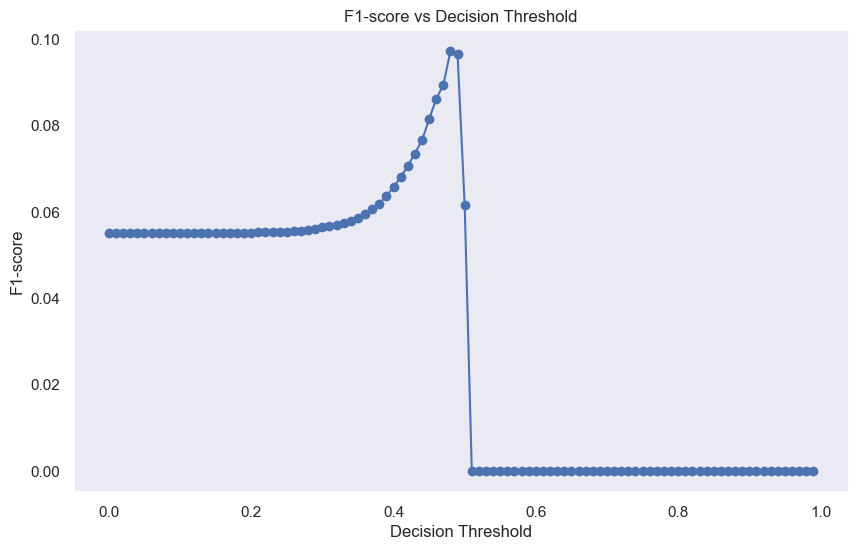

In [7]:
model = StochasticLogisticRegression(lambd=lambda_, lr=lr, debias=True)
model.fit(X_train, y_train, max_iter=max_iter)
best_thres, best_f1, hist = model.find_thresh(X_train, y_train, step=0.01, margin=0)

print(f"Best threshold: {best_thres:.2f} with F1-score: {best_f1:.4f}")

plt.figure(figsize=(10, 6))
plt.plot([h[0] for h in hist], [h[1] for h in hist], marker="o")
plt.title("F1-score vs Decision Threshold")
plt.xlabel("Decision Threshold")
plt.ylabel("F1-score")
plt.grid()
plt.show()

## Training of the model

In [8]:
model_with_mb = StochasticLogisticRegression(
    lambd=lambda_, lr=lr, debias=True, thresh=best_thres
)

# With minibatch (default batch size = 64)
print("With minibatch:")
model_with_mb.fit(X_train, y_train, max_iter=max_iter, minibatch=True)
y_pred = model_with_mb.predict(X_test)

model_with_mb.accuracy_evaluation(
    X_test, y_test, thresh=best_thres, margin=0, vizualisation=True
)


model_without_mb = StochasticLogisticRegression(
    lambd=lambda_, lr=lr, debias=True, thresh=best_thres
)

# Without minibatch
print("Without minibatch:")
model_without_mb.fit(X_train, y_train, max_iter=max_iter, minibatch=False)
y_pred = model_without_mb.predict(X_test)

model_without_mb.accuracy_evaluation(
    X_test, y_test, thresh=best_thres, margin=0, vizualisation=True
);

With minibatch:


100%|██████████| 1000/1000 [00:19<00:00, 50.29it/s]


Good predictions: 75.41%
Undetermined: 0.00%
Wrong predictions: 24.59%
TP: 289 | UP: 0 | FN: 245
TN: 12091 | UN: 0 | FP: 3793
F1-score: 0.1252
Without minibatch:


100%|██████████| 1000/1000 [00:13<00:00, 73.29it/s]

Good predictions: 73.16%
Undetermined: 0.00%
Wrong predictions: 26.84%
TP: 274 | UP: 0 | FN: 260
TN: 11737 | UN: 0 | FP: 4147
F1-score: 0.1106


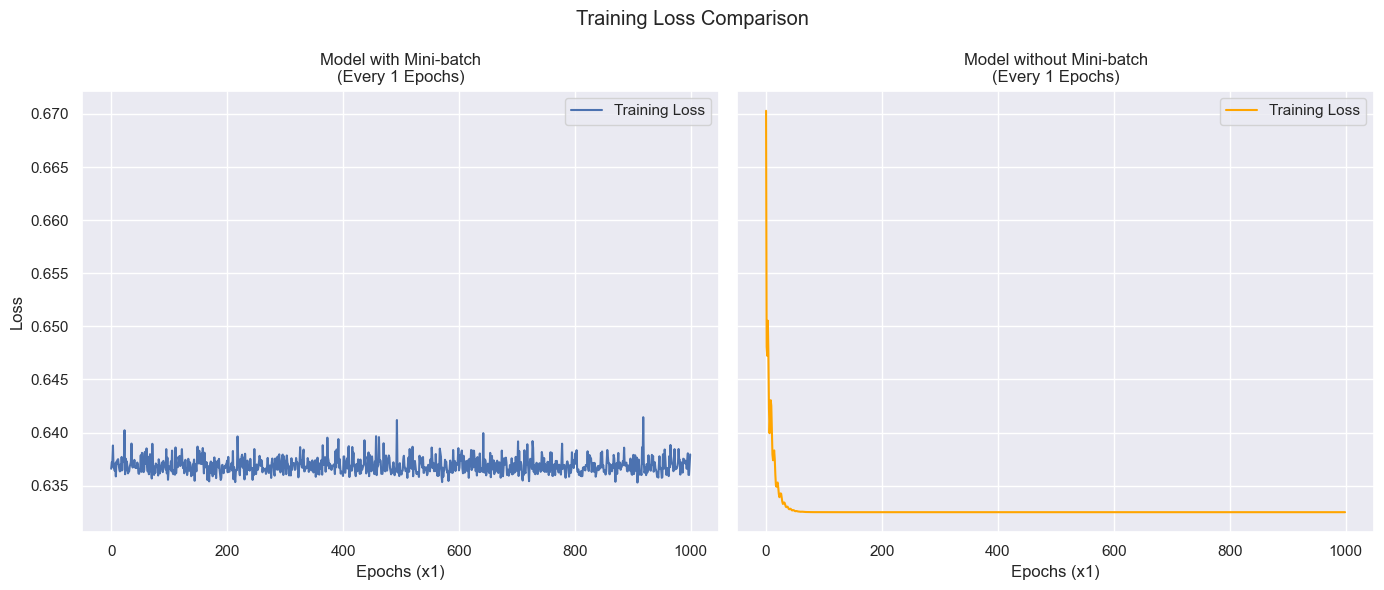

In [9]:
# Training loss comparison
granularity = 1

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# With minibatch
axes[0].plot(model_with_mb.f_history_[::granularity], label="Training Loss")
axes[0].set_title(f"Model with Mini-batch\n(Every {granularity} Epochs)")
axes[0].set_xlabel(f"Epochs (x{granularity})")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Without minibatch
axes[1].plot(
    model_without_mb.f_history_[::granularity], color="orange", label="Training Loss"
)
axes[1].set_title(f"Model without Mini-batch\n(Every {granularity} Epochs)")
axes[1].set_xlabel(f"Epochs (x{granularity})")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Training Loss Comparison")
plt.tight_layout()
plt.show()

Implement only one acceleration method and compare the results

## Study of the batchsize impact

100%|██████████| 1000/1000 [04:30<00:00,  3.70it/s]


Batch size: 1, Accuracy: 0.7125


100%|██████████| 1000/1000 [00:39<00:00, 25.04it/s]


Batch size: 16, Accuracy: 0.7380


100%|██████████| 1000/1000 [00:26<00:00, 37.75it/s]


...

Batch size: 64, Accuracy: 0.6924


100%|██████████| 1000/1000 [00:14<00:00, 68.64it/s]


Batch size: 256, Accuracy: 0.7202


100%|██████████| 1000/1000 [00:13<00:00, 76.58it/s]

Batch size: 1024, Accuracy: 0.7346
Best batch size: 16 with Accuracy: 0.7380


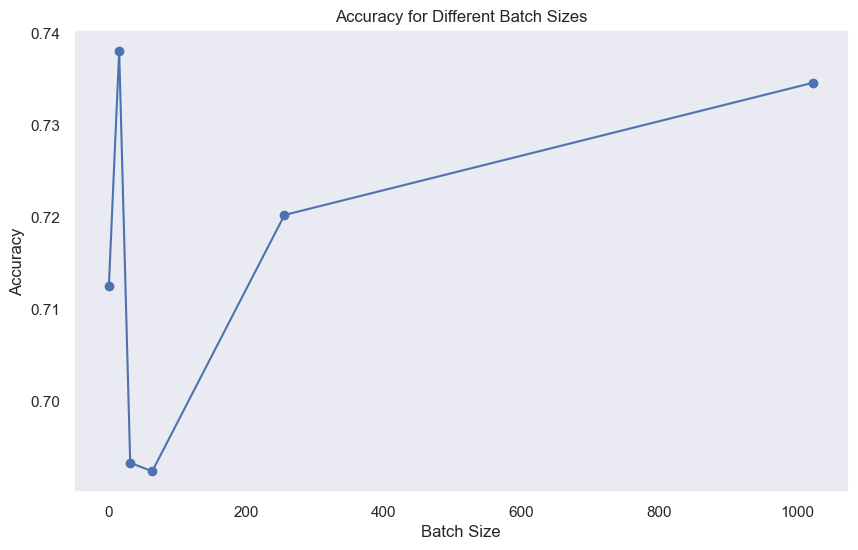

In [10]:
# Accuracy for different hyperparameters
# Batch size
batch_sizes = [1, 16, 32, 64, 256, 1024]
accuracies = []

for bsize in batch_sizes:
    model = StochasticLogisticRegression(
        lambd=lambda_, lr=lr, debias=True, thresh=best_thres
    )
    model.fit(X_train, y_train, max_iter=max_iter, bsize=bsize, minibatch=True)
    y_pred = model.predict(X_test)

    accuracy = np.mean(y_pred == y_test)
    accuracies.append(accuracy)
    print(f"Batch size: {bsize}, Accuracy: {accuracy:.4f}")

print(
    f"Best batch size: {batch_sizes[np.argmax(accuracies)]} with Accuracy: {max(accuracies):.4f}"
)
plt.figure(figsize=(10, 6))
plt.plot(batch_sizes, accuracies, marker="o")
plt.title("Accuracy for Different Batch Sizes")
plt.xlabel("Batch Size")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

# Accuracy Study
## Accuracy over Epochs

100%|██████████| 1000/1000 [00:20<00:00, 49.57it/s]


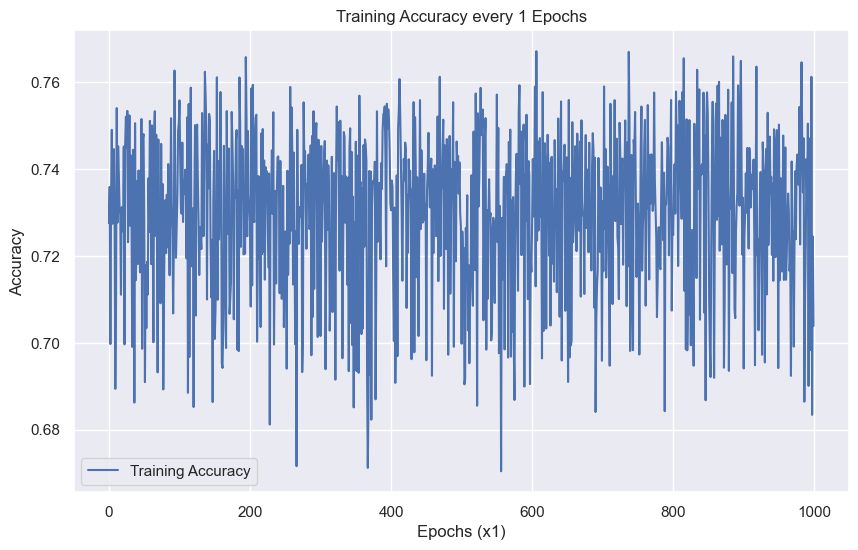

In [11]:
# Accuracy over epochs
granularity = 1

model = StochasticLogisticRegression(
    lambd=lambda_, lr=lr, debias=True, thresh=best_thres
)
model.fit(X_train, y_train, max_iter=max_iter, bsize=64, minibatch=True)
y_pred = model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.plot(model.acc_history_[::granularity], label="Training Accuracy")
plt.title(f"Training Accuracy every {granularity} Epochs")
plt.xlabel(f"Epochs (x{granularity})")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Accuracy for different hyperparameters
We already set lambda = 2, and the learning rate = 0.01. The model is trained on 1000 iterations of batch gradient descent, and we computed the optimal threshold.
We can compare accuracy for different batch sizes, ...

## Gamma impact

100%|██████████| 1000/1000 [00:20<00:00, 49.97it/s]


Gamma: 0.100, Accuracy: 0.6804, F1-score: 0.0902


100%|██████████| 1000/1000 [00:19<00:00, 50.83it/s]


Gamma: 0.200, Accuracy: 0.7146, F1-score: 0.0929


100%|██████████| 1000/1000 [00:19<00:00, 50.87it/s]


...

Gamma: 0.799, Accuracy: 0.7301, F1-score: 0.0981


100%|██████████| 1000/1000 [00:19<00:00, 50.71it/s]


Gamma: 0.899, Accuracy: 0.7338, F1-score: 0.1129


100%|██████████| 1000/1000 [00:20<00:00, 48.13it/s]

Gamma: 0.999, Accuracy: 0.7324, F1-score: 0.1159

Best Gamma (Accuracy): 0.300 with Accuracy: 0.7475
Best Gamma (F1-score): 0.699 with F1-score: 0.1197


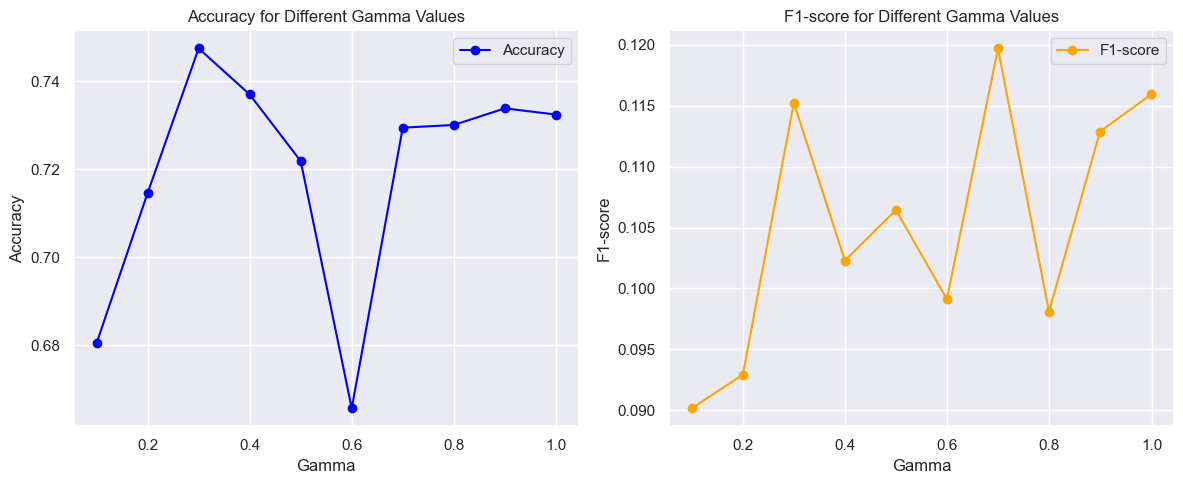

In [12]:
# Accuracy and F1-score for different hyperparameters
# Gamma
gamma_choices = np.linspace(0.1, 0.999, 10)
accuracies = []
f1_scores = []

for g in gamma_choices:
    model = StochasticLogisticRegression(
        lambd=lambda_, lr=lr, gamma=g, debias=True, thresh=best_thres
    )
    model.fit(X_train, y_train, max_iter=max_iter, bsize=64, minibatch=True)
    y_pred = model.predict(X_test)

    accuracy = np.mean(y_pred == y_test)
    f1 = f1_score(y_test, y_pred)

    accuracies.append(accuracy)
    f1_scores.append(f1)

    print(f"Gamma: {g:.3f}, Accuracy: {accuracy:.4f}, F1-score: {f1:.4f}")

print(
    f"\nBest Gamma (Accuracy): {gamma_choices[np.argmax(accuracies)]:.3f} with Accuracy: {max(accuracies):.4f}"
)
print(
    f"Best Gamma (F1-score): {gamma_choices[np.argmax(f1_scores)]:.3f} with F1-score: {max(f1_scores):.4f}"
)

# Plot Accuracy and F1-score in subplots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(gamma_choices, accuracies, marker="o", label="Accuracy", color="blue")
plt.title("Accuracy for Different Gamma Values")
plt.xlabel("Gamma")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(gamma_choices, f1_scores, marker="o", label="F1-score", color="orange")
plt.title("F1-score for Different Gamma Values")
plt.xlabel("Gamma")
plt.ylabel("F1-score")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

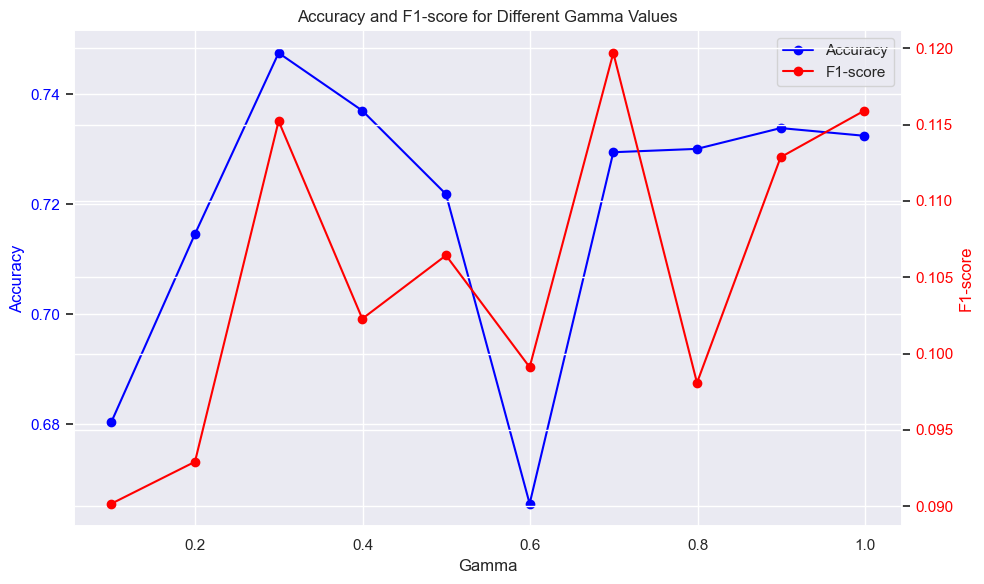

In [13]:
# Combined plot with dual y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

color = "blue"
ax1.set_xlabel("Gamma")
ax1.set_ylabel("Accuracy", color=color)
ax1.plot(gamma_choices, accuracies, marker="o", color=color, label="Accuracy")
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True)

ax2 = ax1.twinx()

color = "red"
ax2.set_ylabel("F1-score", color=color)
ax2.plot(gamma_choices, f1_scores, marker="o", color=color, label="F1-score")
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Accuracy and F1-score for Different Gamma Values")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

fig.tight_layout()
plt.show()


## Beta impact
Nous allons comparer les paramètres beta pour gamma = 0.999 et batch_size=64

100%|██████████| 1000/1000 [00:20<00:00, 49.86it/s]


Beta: 0.100, Accuracy: 0.7032, F1-score: 0.0951


100%|██████████| 1000/1000 [00:20<00:00, 49.75it/s]


Beta: 0.200, Accuracy: 0.7288, F1-score: 0.1067


100%|██████████| 1000/1000 [00:20<00:00, 49.28it/s]


...

Beta: 0.799, Accuracy: 0.7203, F1-score: 0.1094


100%|██████████| 1000/1000 [00:19<00:00, 50.66it/s]


Beta: 0.899, Accuracy: 0.7318, F1-score: 0.1196


100%|██████████| 1000/1000 [00:19<00:00, 50.77it/s]

Beta: 0.999, Accuracy: 0.7437, F1-score: 0.1193

Best Beta (Accuracy): 0.999 with Accuracy: 0.7437
Best Beta (F1-score): 0.500 with F1-score: 0.1263


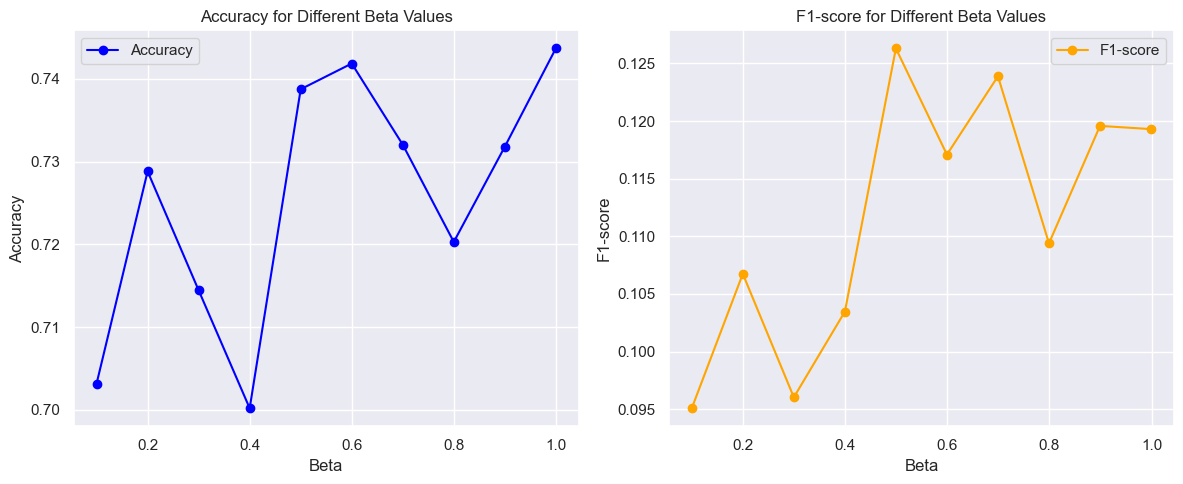

In [14]:
# Accuracy and F1-score for different hyperparameters
# Beta
beta_choices = np.linspace(0.1, 0.999, 10)
accuracies = []
f1_scores = []

for b in beta_choices:
    model = StochasticLogisticRegression(
        lambd=lambda_, lr=lr, beta=b, gamma=0.999, debias=True, thresh=best_thres
    )
    model.fit(X_train, y_train, max_iter=max_iter, bsize=64, minibatch=True)
    y_pred = model.predict(X_test)

    accuracy = np.mean(y_pred == y_test)
    f1 = f1_score(y_test, y_pred)

    accuracies.append(accuracy)
    f1_scores.append(f1)

    print(f"Beta: {b:.3f}, Accuracy: {accuracy:.4f}, F1-score: {f1:.4f}")

print(
    f"\nBest Beta (Accuracy): {beta_choices[np.argmax(accuracies)]:.3f} with Accuracy: {max(accuracies):.4f}"
)
print(
    f"Best Beta (F1-score): {beta_choices[np.argmax(f1_scores)]:.3f} with F1-score: {max(f1_scores):.4f}"
)

# Plot Accuracy and F1-score in subplots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(beta_choices, accuracies, marker="o", label="Accuracy", color="blue")
plt.title("Accuracy for Different Beta Values")
plt.xlabel("Beta")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(beta_choices, f1_scores, marker="o", label="F1-score", color="orange")
plt.title("F1-score for Different Beta Values")
plt.xlabel("Beta")
plt.ylabel("F1-score")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

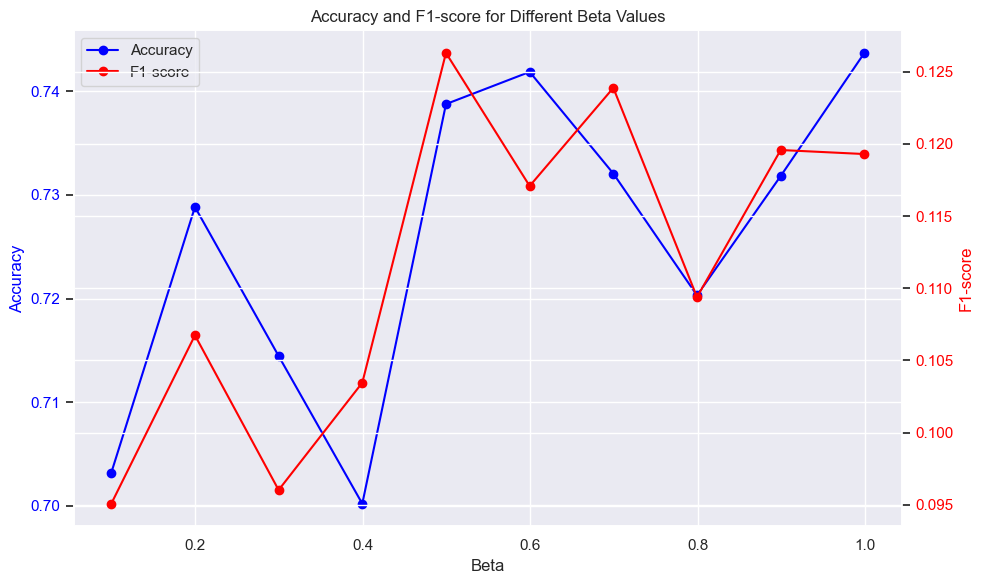

In [15]:
# Combined plot with dual y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

color = "blue"
ax1.set_xlabel("Beta")
ax1.set_ylabel("Accuracy", color=color)
ax1.plot(beta_choices, accuracies, marker="o", color=color, label="Accuracy")
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True)

ax2 = ax1.twinx()

color = "red"
ax2.set_ylabel("F1-score", color=color)
ax2.plot(beta_choices, f1_scores, marker="o", color=color, label="F1-score")
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Accuracy and F1-score for Different Beta Values")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

fig.tight_layout()
plt.show()
